# Import Data 

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm 
from sklearn.linear_model import LinearRegression
import seaborn as sns 
from IPython.display import display 
sns.set()

# Data

In [6]:
data_raw = pd.read_csv(r'C:\Users\abudi\Downloads\jakarta_house.csv')
display(data_raw)

,index,price,district,city,bed_rooms,bath_rooms,carport,land_area,building_area
0,1,5900000000,Citra Garden,Jakarta Barat,2,4,2,250.0,350.0
1,2,2700000000,Jelambar,Jakarta Barat,4,2,0,100.0,225.0
2,3,2200000000,Jelambar,Jakarta Barat,3,3,0,60.0,140.0
3,4,1900000000,Jelambar,Jakarta Barat,3,2,0,60.0,120.0
4,5,2100000000,Tanjung Duren,Jakarta Barat,4,3,0,56.0,108.0
...,...,...,...,...,...,...,...,...,...
9995,9996,5500000000,Kemang,Jakarta Selatan,3,4,0,90.0,180.0
9996,9997,10000000000,Cipete,Jakarta Selatan,4,4,0,431.0,308.0
9997,9998,450000000,Pasar Minggu,Jakarta Selatan,2,1,0,62.0,55.0
9998,9999,8900000000,Kelapa Gading,Jakarta Utara,0,0,0,249.0,300.0


# Prepocessing Data 

## Explore Data 

In [9]:
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          10000 non-null  int64  
 1   price          10000 non-null  int64  
 2   district       10000 non-null  object 
 3   city           10000 non-null  object 
 4   bed_rooms      10000 non-null  int64  
 5   bath_rooms     10000 non-null  int64  
 6   carport        10000 non-null  int64  
 7   land_area      9997 non-null   float64
 8   building_area  9995 non-null   float64
dtypes: float64(2), int64(5), object(2)
memory usage: 703.3+ KB


In [10]:
data_raw.describe()

,index,price,bed_rooms,bath_rooms,carport,land_area,building_area
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,9997.000000,9995.000000
mean,5000.50000,1.004029e+10,4.253500,3.521300,1.578900,296.610183,319.962481
std,2886.89568,2.004519e+10,3.176609,2.900136,1.743467,502.921686,357.676034
min,1.00000,1.850000e+06,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2500.75000,2.500000e+09,3.000000,2.000000,1.000000,100.000000,139.000000
50%,5000.50000,4.500000e+09,4.000000,3.000000,1.000000,177.000000,230.000000
75%,7500.25000,9.800000e+09,5.000000,4.000000,2.000000,335.000000,400.000000
max,10000.00000,9.000000e+11,63.000000,63.000000,31.000000,17714.000000,15331.000000


In [11]:
data_raw.describe(include='all')

,index,price,district,city,bed_rooms,bath_rooms,carport,land_area,building_area
count,10000.00000,1.000000e+04,10000,10000,10000.000000,10000.000000,10000.000000,9997.000000,9995.000000
unique,NaN,NaN,253,5,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Kelapa Gading,Jakarta Selatan,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,435,3379,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,1.004029e+10,NaN,NaN,4.253500,3.521300,1.578900,296.610183,319.962481
std,2886.89568,2.004519e+10,NaN,NaN,3.176609,2.900136,1.743467,502.921686,357.676034
min,1.00000,1.850000e+06,NaN,NaN,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2500.75000,2.500000e+09,NaN,NaN,3.000000,2.000000,1.000000,100.000000,139.000000
50%,5000.50000,4.500000e+09,NaN,NaN,4.000000,3.000000,1.000000,177.000000,230.000000
75%,7500.25000,9.800000e+09,NaN,NaN,5.000000,4.000000,2.000000,335.000000,400.000000


In [12]:
data = data_raw.drop(['district','index'], axis = 1)
data.describe(include='all')

,price,city,bed_rooms,bath_rooms,carport,land_area,building_area
count,1.000000e+04,10000,10000.000000,10000.000000,10000.000000,9997.000000,9995.000000
unique,NaN,5,NaN,NaN,NaN,NaN,NaN
top,NaN,Jakarta Selatan,NaN,NaN,NaN,NaN,NaN
freq,NaN,3379,NaN,NaN,NaN,NaN,NaN
mean,1.004029e+10,NaN,4.253500,3.521300,1.578900,296.610183,319.962481
std,2.004519e+10,NaN,3.176609,2.900136,1.743467,502.921686,357.676034
min,1.850000e+06,NaN,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2.500000e+09,NaN,3.000000,2.000000,1.000000,100.000000,139.000000
50%,4.500000e+09,NaN,4.000000,3.000000,1.000000,177.000000,230.000000
75%,9.800000e+09,NaN,5.000000,4.000000,2.000000,335.000000,400.000000


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          10000 non-null  int64  
 1   city           10000 non-null  object 
 2   bed_rooms      10000 non-null  int64  
 3   bath_rooms     10000 non-null  int64  
 4   carport        10000 non-null  int64  
 5   land_area      9997 non-null   float64
 6   building_area  9995 non-null   float64
dtypes: float64(2), int64(4), object(1)
memory usage: 547.0+ KB


## Handling Missing Values

In [15]:
data.isnull().sum()

price            0
city             0
bed_rooms        0
bath_rooms       0
carport          0
land_area        3
building_area    5
dtype: int64

In [16]:
data_no_mv = data.dropna(axis=0)
data_no_mv.describe(include='all')

,price,city,bed_rooms,bath_rooms,carport,land_area,building_area
count,9.992000e+03,9992,9992.000000,9992.000000,9992.000000,9992.000000,9992.000000
unique,NaN,5,NaN,NaN,NaN,NaN,NaN
top,NaN,Jakarta Selatan,NaN,NaN,NaN,NaN,NaN
freq,NaN,3379,NaN,NaN,NaN,NaN,NaN
mean,1.003935e+10,NaN,4.252702,3.521417,1.579363,296.638311,319.919235
std,2.005052e+10,NaN,3.176976,2.900295,1.743859,503.038116,357.694301
min,1.850000e+06,NaN,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2.500000e+09,NaN,3.000000,2.000000,1.000000,100.000000,139.000000
50%,4.500000e+09,NaN,4.000000,3.000000,1.000000,177.000000,230.000000
75%,9.800000e+09,NaN,5.000000,4.000000,2.000000,335.000000,400.000000


## Exploring PDFs

### Price

<Axes: xlabel='price', ylabel='Count'>

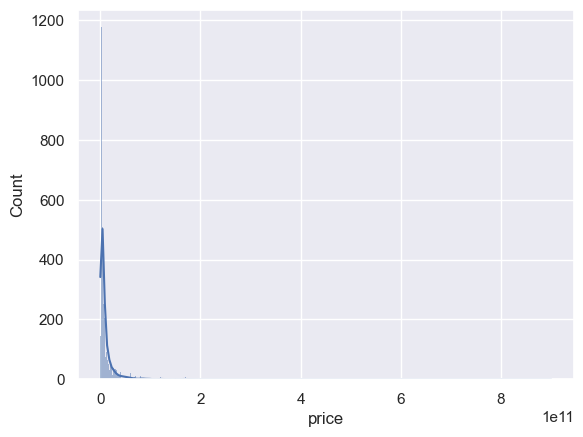

In [19]:
sns.histplot(data_no_mv['price'], kde = True)

In [20]:
q_high_price = data_no_mv['price'].quantile(0.99)
q_low_price = data_no_mv['price'].quantile(0.01)

data_1 = data_no_mv[
(data_no_mv['price']>q_low_price) & (data_no_mv['price']<q_high_price)
 ]

<Axes: xlabel='price', ylabel='Count'>

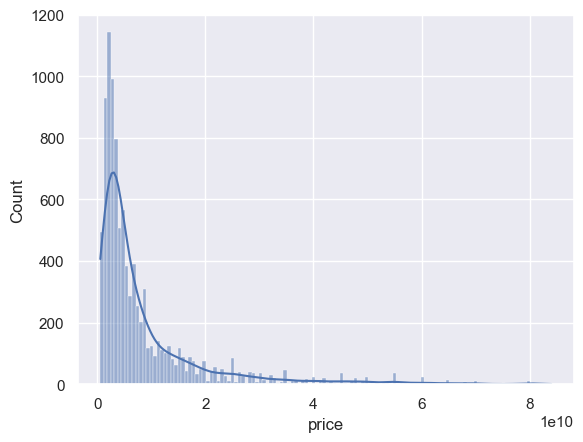

In [21]:
sns.histplot(data_1['price'], kde=True)

In [22]:
data_1.describe(include='all')

,price,city,bed_rooms,bath_rooms,carport,land_area,building_area
count,9.782000e+03,9782,9782.000000,9782.000000,9782.000000,9782.000000,9782.000000
unique,NaN,5,NaN,NaN,NaN,NaN,NaN
top,NaN,Jakarta Selatan,NaN,NaN,NaN,NaN,NaN
freq,NaN,3295,NaN,NaN,NaN,NaN,NaN
mean,8.700972e+09,NaN,4.252709,3.516561,1.556328,278.802188,309.592926
std,1.130504e+10,NaN,3.165724,2.871811,1.648255,330.119194,278.866197
min,5.600000e+08,NaN,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2.500000e+09,NaN,3.000000,2.000000,1.000000,102.000000,140.000000
50%,4.500000e+09,NaN,4.000000,3.000000,1.000000,176.000000,228.000000
75%,9.500000e+09,NaN,5.000000,4.000000,2.000000,326.000000,400.000000


### bed_rooms 

<Axes: xlabel='bed_rooms', ylabel='Count'>

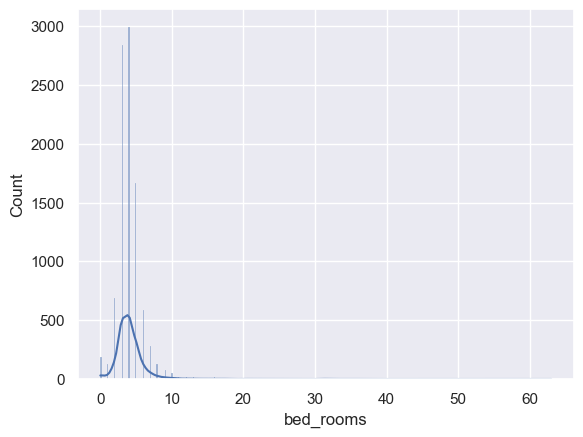

In [24]:
sns.histplot(data_1['bed_rooms'], kde = True)

In [25]:
q = data_1['bed_rooms'].quantile(0.99)
data_2 = data_1[data_1['bed_rooms']<q]

<Axes: xlabel='bed_rooms', ylabel='Count'>

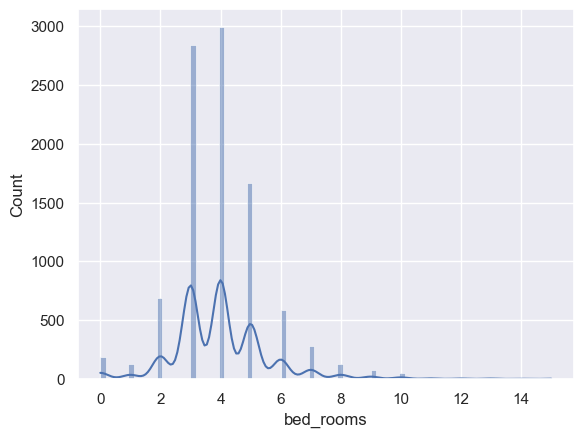

In [26]:
sns.histplot(data_2['bed_rooms'], kde = True)

In [27]:
data_2.describe(include='all')

,price,city,bed_rooms,bath_rooms,carport,land_area,building_area
count,9.683000e+03,9683,9683.000000,9683.000000,9683.000000,9683.000000,9683.000000
unique,NaN,5,NaN,NaN,NaN,NaN,NaN
top,NaN,Jakarta Selatan,NaN,NaN,NaN,NaN,NaN
freq,NaN,3264,NaN,NaN,NaN,NaN,NaN
mean,8.663901e+09,NaN,4.009295,3.321388,1.545182,277.664257,306.046163
std,1.129800e+10,NaN,1.671577,1.506710,1.601712,329.258504,274.487683
min,5.600000e+08,NaN,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2.500000e+09,NaN,3.000000,2.000000,1.000000,102.000000,140.000000
50%,4.420000e+09,NaN,4.000000,3.000000,1.000000,174.000000,225.000000
75%,9.500000e+09,NaN,5.000000,4.000000,2.000000,325.000000,390.000000


## bath_rooms

<Axes: xlabel='bath_rooms', ylabel='Count'>

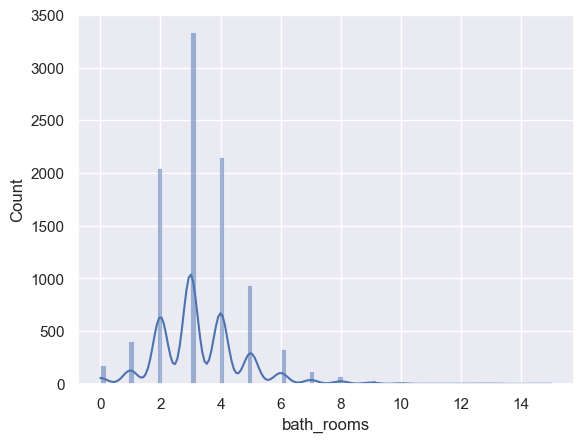

In [29]:
sns.histplot(data_2['bath_rooms'], kde = True)

In [30]:
q = data_2['bath_rooms'].quantile(0.99)
data_3 = data_2[data_2['bath_rooms']<q]

<Axes: xlabel='bath_rooms', ylabel='Count'>

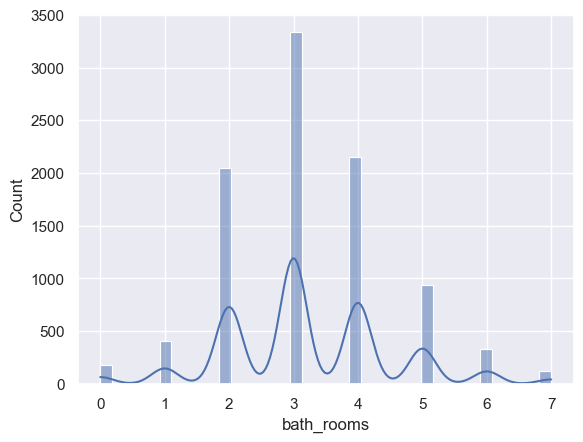

In [31]:
sns.histplot(data_3['bath_rooms'], kde = True)

In [32]:
data_3.describe(include='all')

,price,city,bed_rooms,bath_rooms,carport,land_area,building_area
count,9.519000e+03,9519,9519.000000,9519.000000,9519.000000,9519.000000,9519.000000
unique,NaN,5,NaN,NaN,NaN,NaN,NaN
top,NaN,Jakarta Selatan,NaN,NaN,NaN,NaN,NaN
freq,NaN,3196,NaN,NaN,NaN,NaN,NaN
mean,8.381081e+09,NaN,3.925097,3.219981,1.521588,271.561193,296.904192
std,1.085830e+10,NaN,1.518451,1.283978,1.559741,322.424688,256.578286
min,5.600000e+08,NaN,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2.500000e+09,NaN,3.000000,2.000000,1.000000,100.000000,137.500000
50%,4.300000e+09,NaN,4.000000,3.000000,1.000000,170.000000,220.000000
75%,9.000000e+09,NaN,5.000000,4.000000,2.000000,319.000000,375.000000


## carport 

<Axes: xlabel='carport', ylabel='Count'>

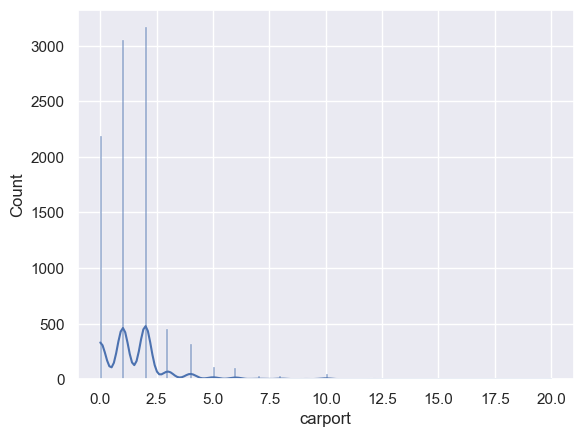

In [34]:
sns.histplot(data_3['carport'], kde = True)

In [35]:
q = data_3['carport'].quantile(0.99)
data_4 = data_3[data_3['carport']<q]

<Axes: xlabel='carport', ylabel='Count'>

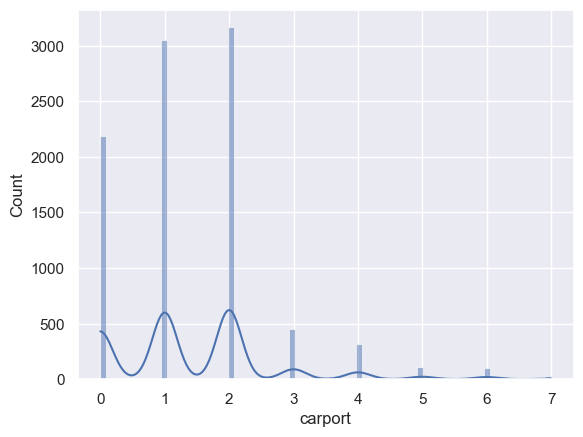

In [36]:
sns.histplot(data_4['carport'], kde = True)

In [37]:
data_4.describe(include = 'all')

,price,city,bed_rooms,bath_rooms,carport,land_area,building_area
count,9.403000e+03,9403,9403.000000,9403.000000,9403.000000,9403.000000,9403.000000
unique,NaN,5,NaN,NaN,NaN,NaN,NaN
top,NaN,Jakarta Selatan,NaN,NaN,NaN,NaN,NaN
freq,NaN,3105,NaN,NaN,NaN,NaN,NaN
mean,8.120622e+09,NaN,3.911837,3.210677,1.414549,260.060619,292.889610
std,1.044406e+10,NaN,1.505500,1.279061,1.195703,277.157638,251.909017
min,5.600000e+08,NaN,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2.500000e+09,NaN,3.000000,2.000000,1.000000,100.000000,135.000000
50%,4.250000e+09,NaN,4.000000,3.000000,1.000000,166.000000,219.000000
75%,8.900000e+09,NaN,5.000000,4.000000,2.000000,311.000000,370.000000


## land_area

<Axes: xlabel='land_area', ylabel='Count'>

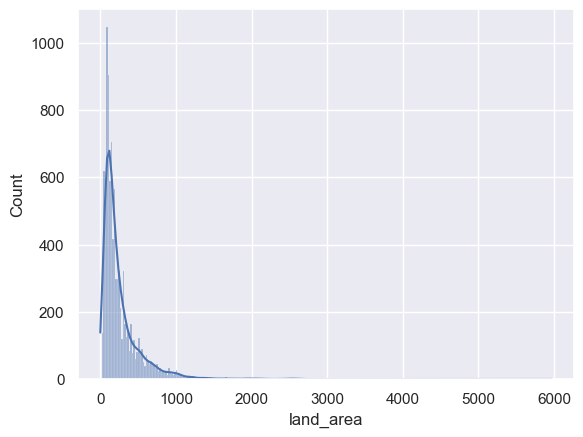

In [39]:
sns.histplot(data_4['land_area'], kde = True)

In [40]:
q = data_4['land_area'].quantile(0.99)
data_5 = data_4[data_4['land_area']<q]

<Axes: xlabel='land_area', ylabel='Count'>

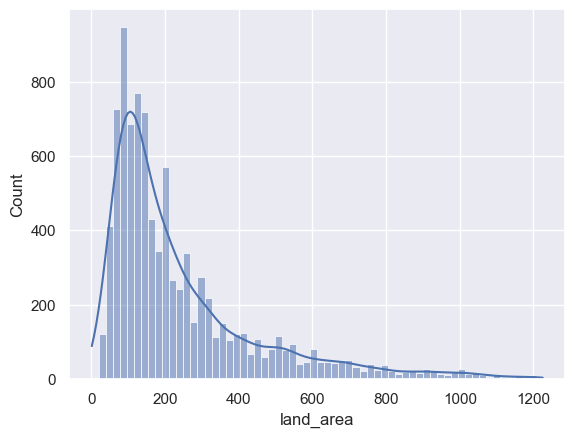

In [41]:
sns.histplot(data_5['land_area'], kde=True)

In [42]:
data_5.describe(include='all')

,price,city,bed_rooms,bath_rooms,carport,land_area,building_area
count,9.308000e+03,9308,9308.000000,9308.000000,9308.000000,9308.000000,9308.000000
unique,NaN,5,NaN,NaN,NaN,NaN,NaN
top,NaN,Jakarta Selatan,NaN,NaN,NaN,NaN,NaN
freq,NaN,3033,NaN,NaN,NaN,NaN,NaN
mean,7.836491e+09,NaN,3.903309,3.202729,1.402127,243.864310,286.795875
std,9.930687e+09,NaN,1.497427,1.271150,1.170435,213.496011,236.237944
min,5.600000e+08,NaN,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2.450000e+09,NaN,3.000000,2.000000,1.000000,100.000000,135.000000
50%,4.200000e+09,NaN,4.000000,3.000000,1.000000,162.000000,214.500000
75%,8.700000e+09,NaN,5.000000,4.000000,2.000000,304.000000,360.000000


## building_area

<Axes: xlabel='building_area', ylabel='Count'>

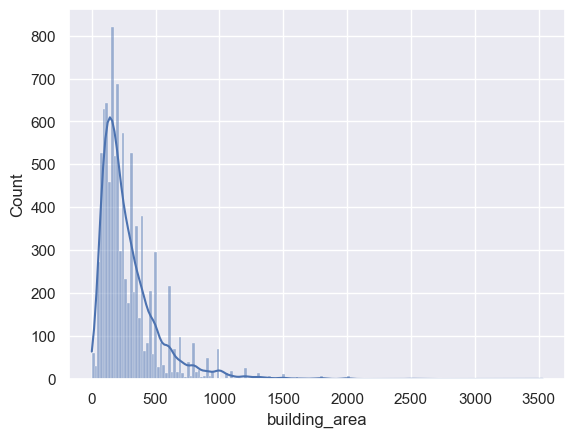

In [44]:
sns.histplot(data_5['building_area'], kde = True)

In [45]:
q = data_5['building_area'].quantile(0.99)
data_6 = data_5[data_5['building_area']<q]

<Axes: xlabel='building_area', ylabel='Count'>

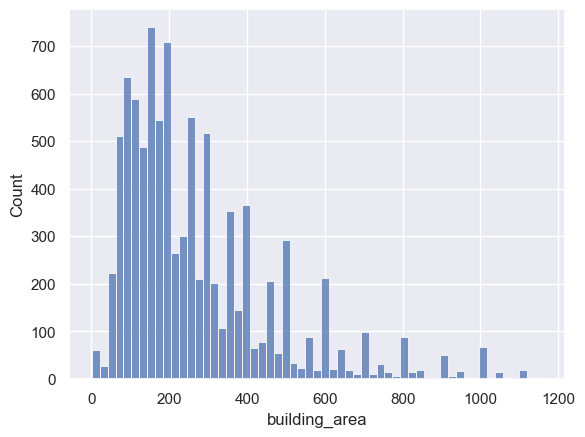

In [46]:
sns.histplot(data_6['building_area'])

In [47]:
data_6.describe(include='all')

,price,city,bed_rooms,bath_rooms,carport,land_area,building_area
count,9.209000e+03,9209,9209.000000,9209.000000,9209.000000,9209.000000,9209.000000
unique,NaN,5,NaN,NaN,NaN,NaN,NaN
top,NaN,Jakarta Selatan,NaN,NaN,NaN,NaN,NaN
freq,NaN,2989,NaN,NaN,NaN,NaN,NaN
mean,7.529402e+09,NaN,3.889782,3.188620,1.393202,238.296992,273.802910
std,9.362060e+09,NaN,1.484979,1.253465,1.154883,206.182774,197.389581
min,5.600000e+08,NaN,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2.400000e+09,NaN,3.000000,2.000000,1.000000,100.000000,134.000000
50%,4.100000e+09,NaN,4.000000,3.000000,1.000000,161.000000,210.000000
75%,8.500000e+09,NaN,5.000000,4.000000,2.000000,300.000000,350.000000


In [48]:
data_cleaned = data_6.reset_index(drop=True)

# Checking the OLS Assumptions

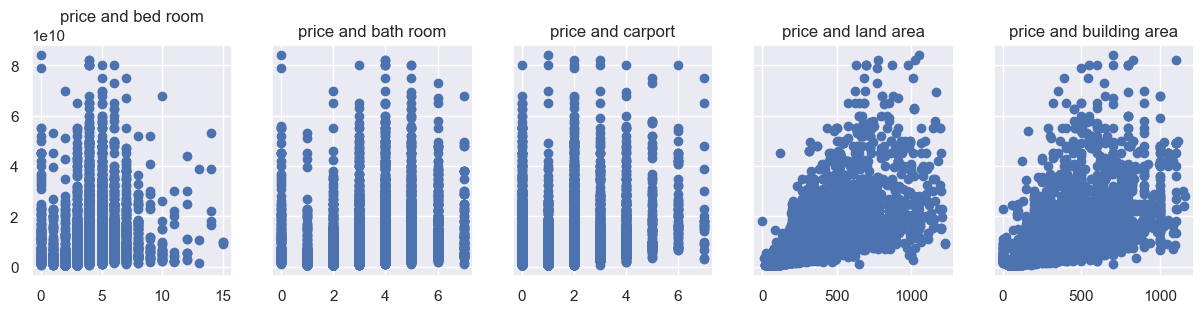

In [50]:
f, (ax1,ax2,ax3,ax4,ax5) = plt.subplots(1,5, sharey = True, figsize=(15,3))
ax1.scatter(data_cleaned['bed_rooms'],data_cleaned['price'])
ax1.set_title('price and bed room')
ax2.scatter(data_cleaned['bath_rooms'],data_cleaned['price'])
ax2.set_title('price and bath room')
ax3.scatter(data_cleaned['carport'],data_cleaned['price'])
ax3.set_title('price and carport')
ax4.scatter(data_cleaned['land_area'],data_cleaned['price'])
ax4.set_title('price and land area')
ax5.scatter(data_cleaned['building_area'],data_cleaned['price'])
ax5.set_title('price and building area')
plt.show()

In [51]:
log_price = np.log(data_cleaned['price'])
data_cleaned['log_price'] = log_price
data_cleaned.head()

,price,city,bed_rooms,bath_rooms,carport,land_area,building_area,log_price
0,5900000000,Jakarta Barat,2,4,2,250.0,350.0,22.498218
1,2700000000,Jakarta Barat,4,2,0,100.0,225.0,21.716518
2,2200000000,Jakarta Barat,3,3,0,60.0,140.0,21.511723
3,1900000000,Jakarta Barat,3,2,0,60.0,120.0,21.365120
4,2100000000,Jakarta Barat,4,3,0,56.0,108.0,21.465203


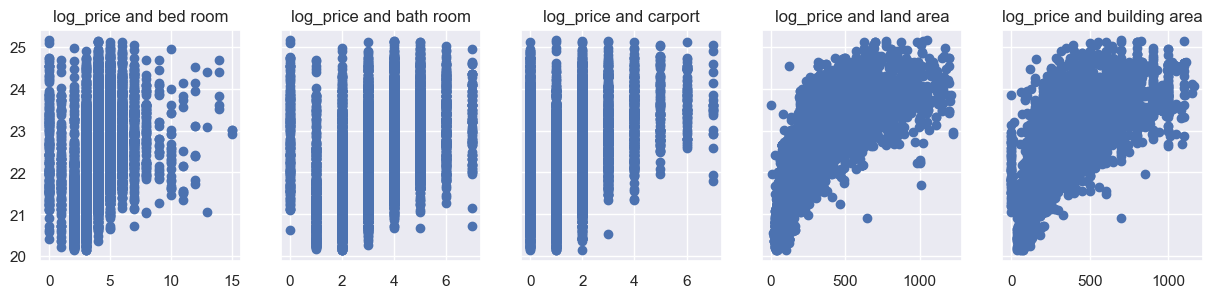

In [52]:
f, (ax1,ax2,ax3,ax4,ax5) = plt.subplots(1,5, sharey = True, figsize=(15,3))
ax1.scatter(data_cleaned['bed_rooms'],data_cleaned['log_price'])
ax1.set_title('log_price and bed room')
ax2.scatter(data_cleaned['bath_rooms'],data_cleaned['log_price'])
ax2.set_title('log_price and bath room')
ax3.scatter(data_cleaned['carport'],data_cleaned['log_price'])
ax3.set_title('log_price and carport')
ax4.scatter(data_cleaned['land_area'],data_cleaned['log_price'])
ax4.set_title('log_price and land area')
ax5.scatter(data_cleaned['building_area'],data_cleaned['log_price'])
ax5.set_title('log_price and building area')
plt.show()

## Create Dummy Variables

In [54]:
data_with_dummies = pd.get_dummies(data_cleaned, drop_first=True)
dummy_columns = data_with_dummies.select_dtypes(include='bool').columns
data_with_dummies[dummy_columns] = data_with_dummies[dummy_columns].astype(int)

In [55]:
data_with_dummies.head()

,price,bed_rooms,bath_rooms,carport,land_area,building_area,log_price,city_Jakarta Pusat,city_Jakarta Selatan,city_Jakarta Timur,city_Jakarta Utara
0,5900000000,2,4,2,250.0,350.0,22.498218,0,0,0,0
1,2700000000,4,2,0,100.0,225.0,21.716518,0,0,0,0
2,2200000000,3,3,0,60.0,140.0,21.511723,0,0,0,0
3,1900000000,3,2,0,60.0,120.0,21.365120,0,0,0,0
4,2100000000,4,3,0,56.0,108.0,21.465203,0,0,0,0


In [56]:
data_with_dummies.columns.values

array(['price', 'bed_rooms', 'bath_rooms', 'carport', 'land_area',
       'building_area', 'log_price', 'city_Jakarta Pusat',
       'city_Jakarta Selatan', 'city_Jakarta Timur', 'city_Jakarta Utara'],
      dtype=object)

In [57]:
cols = ['price', 'bed_rooms', 'bath_rooms', 'carport', 'land_area',
       'building_area', 'log_price', 'city_Jakarta Pusat',
       'city_Jakarta Selatan', 'city_Jakarta Timur', 'city_Jakarta Utara']

In [58]:
data_prepocessed = data_with_dummies[cols]

In [59]:
data_prepocessed.head()

,price,bed_rooms,bath_rooms,carport,land_area,building_area,log_price,city_Jakarta Pusat,city_Jakarta Selatan,city_Jakarta Timur,city_Jakarta Utara
0,5900000000,2,4,2,250.0,350.0,22.498218,0,0,0,0
1,2700000000,4,2,0,100.0,225.0,21.716518,0,0,0,0
2,2200000000,3,3,0,60.0,140.0,21.511723,0,0,0,0
3,1900000000,3,2,0,60.0,120.0,21.365120,0,0,0,0
4,2100000000,4,3,0,56.0,108.0,21.465203,0,0,0,0


# Linear Regression Model 

In [61]:
targets = data_prepocessed['log_price']
inputs = data_prepocessed.drop(['price','log_price'], axis=1)

In [62]:
from sklearn.model_selection import train_test_split 
x_train, x_test, y_train, y_test = train_test_split(
inputs, targets, test_size=0.2, random_state = 365)

In [63]:
reg = LinearRegression()
reg.fit(x_train,y_train)
y_hat = reg.predict(x_train)

In [64]:
y_hat = reg.predict(x_train)

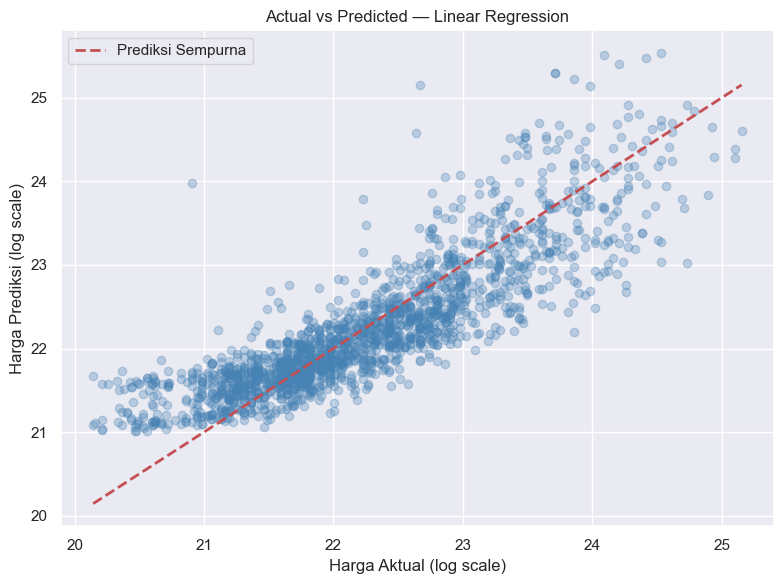

In [65]:
y_pred_lr = reg.predict(x_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Prediksi Sempurna')
plt.xlabel('Harga Aktual (log scale)')
plt.ylabel('Harga Prediksi (log scale)')
plt.title('Actual vs Predicted — Linear Regression')
plt.legend()
plt.tight_layout()
plt.show()

In [66]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, reg.predict(x_test)))
print("RMSE:", np.sqrt(mean_squared_error(y_test, reg.predict(x_test))))
print("R2:", r2_score(y_test, reg.predict(x_test)))

MAE: 0.3560533576254151
RMSE: 0.47298211322390593
R2: 0.7411146677995908


# Random Forest

In [68]:
from sklearn.ensemble import RandomForestRegressor

In [69]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=365
)

In [70]:
rf.fit(x_train, y_train)

RandomForestRegressor(random_state=365)

In [71]:
print(y_pred_rf.min())
print(y_pred_rf.max())

NameError: name 'y_pred_rf' is not defined

In [ ]:
y_pred_rf = rf.predict(x_test)

In [ ]:
y_pred_rf = rf.predict(x_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Prediksi Sempurna')
plt.xlabel('Harga Aktual (log scale)')
plt.ylabel('Harga Prediksi (log scale)')
plt.title('Actual vs Predicted — Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

## Feature Important 

In [ ]:
importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

## Making Prediction 

In [ ]:
def prediksi_harga(
    bed_rooms,
    bath_rooms,
    carport,
    land_area,
    building_area,
    kota
):
    rumah = {
        'bed_rooms': bed_rooms,
        'bath_rooms': bath_rooms,
        'carport': carport,
        'land_area': land_area,
        'building_area': building_area,
        'city_Jakarta Pusat': 0,
        'city_Jakarta Selatan': 0,
        'city_Jakarta Timur': 0,
        'city_Jakarta Utara': 0
    }
    if kota == "Jakarta Pusat":
        rumah['city_Jakarta Pusat'] = 1

    elif kota == "Jakarta Selatan":
        rumah['city_Jakarta Selatan'] = 1

    elif kota == "Jakarta Timur":
        rumah['city_Jakarta Timur'] = 1

    elif kota == "Jakarta Utara":
        rumah['city_Jakarta Utara'] = 1  
    rumah = pd.DataFrame([rumah])
    pred_log = rf.predict(rumah)
    pred_harga = np.exp(pred_log)
    return pred_harga[0]

## Input Data Rumah

In [ ]:
# Taruh semua data input di sini
df_input = pd.DataFrame({
    'bed_rooms':     [4, 3, 5, 2,6],
    'bath_rooms':    [3, 2, 4, 1, 3],
    'carport':       [2, 1, 3, 2, 4],
    'land_area':     [200, 150, 300, 136, 450],
    'building_area': [150, 100, 250, 100, 300],
    'kota':          ["Jakarta Selatan", "Jakarta Pusat", "Jakarta Utara", "Jakarta Timur", "Jakarta Barat"]
})

# Prediksi otomatis langsung jadi kolom baru
df_input['prediksi_harga'] = df_input.apply(
    lambda row: prediksi_harga(
        bed_rooms=row['bed_rooms'],
        bath_rooms=row['bath_rooms'],
        carport=row['carport'],
        land_area=row['land_area'],
        building_area=row['building_area'],
        kota=row['kota']
    ), axis=1
)

display(df_input.style.format({'prediksi_harga': 'Rp {:,.0f}'}))

In [ ]:
metrics = ['MAE', 'RMSE', 'R2']
lr_scores = [0.3561, 0.4730, 0.7411]
rf_scores = [0.2495, 0.3563, 0.8531]
x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, lr_scores, width, label='Linear Regression', color='steelblue')
ax.bar(x + width/2, rf_scores, width, label='Random Forest', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title('Perbandingan Performa Model')
ax.set_ylabel('Nilai')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Random Forest Regressor')
plt.xlabel('Tingkat Kepentingan')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

In [ ]:
import pickle, os
os.makedirs('model', exist_ok=True)
with open('model/rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)